In natural language processing and machine learning Naive Bayes is a popular method for classifying text documents

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer #convert text data into numerical features using word count
from sklearn.naive_bayes import MultinomialNB #naive bayes classifier for multinomial data
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
data=pd.read_csv('synthetic_text_data.csv')
data.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


In [4]:
X=data['text']
y=data['label']

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

CountVectorizer()

This is a tool from scikit-learn used for text preprocessing.

It converts a collection of text documents into a matrix of token counts (also called a "bag-of-words" representation).

Example:

Input: ["I love AI", "AI loves me"]

Output vocabulary: {'ai':0, 'love':1, 'loves':2, 'me':3, 'i':4}

CountVectorizer converts text into numbers (word counts).

fit_transform builds the vocabulary from training data and encodes it.

transform applies that vocabulary to test data, ensuring both sets use the same word mapping.

In [6]:
vectorizer=CountVectorizer()
X_train_vectorized=vectorizer.fit_transform(X_train)
X_train_vectorized
X_test_vectorized=vectorizer.transform(X_test)
X_test_vectorized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 136 stored elements and shape (17, 395)>

In [7]:
model=MultinomialNB()
model.fit(X_train_vectorized,y_train)

MultinomialNB()

In [8]:
y_pred=model.predict(X_test_vectorized)

In [10]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8823529411764706

In [11]:
conf_matrix=confusion_matrix(y_test,y_pred)
conf_matrix

array([[2, 0, 0, 0],
       [0, 5, 0, 0],
       [0, 0, 2, 1],
       [1, 0, 0, 6]])

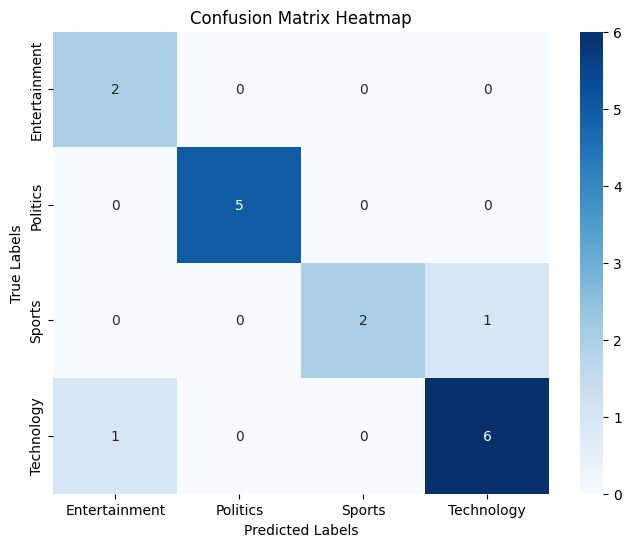

In [17]:
class_labels=np.unique(y_test)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',xticklabels=class_labels,yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


